In [27]:
import pandas as pd
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('s7.csv')

imgs_folder = 'data/mskcc/images'


df.head()

,Unnamed: 0,isic_id,dermoscopic_type,img_l,img_a,img_b,img_ita,tag_id,type,anatomic_site,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,1,ISIC_6369402,NP-C,66.64,14.82,-5.97,-70.263331,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
1,2,ISIC_6052854,P-C,67.81,13.69,1.41,85.473392,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
2,3,ISIC_7075171,P-NC,64.19,17.55,1.44,84.205466,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
3,4,ISIC_5473699,NP-NC,63.70,18.36,-7.77,-60.440118,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
4,5,ISIC_3868399,P-C,70.05,10.21,1.82,84.813301,105266,normal-skin,upper chest,...,9.0,8.66,12,12.0,11.0,11.66,48,50.0,49.0,49.00


Color in image (LAB):  [np.float64(146.36999999999998) np.float64(140.69) np.float64(129.39)]
Physical color (LAB):  [np.float64(160.64999999999998) np.float64(130.33) np.float64(150.0)]
Correction value (LAB):  [np.float64(1.0975609756097562) np.float64(0.9263629255810648)
 np.float64(1.159285879897983)]


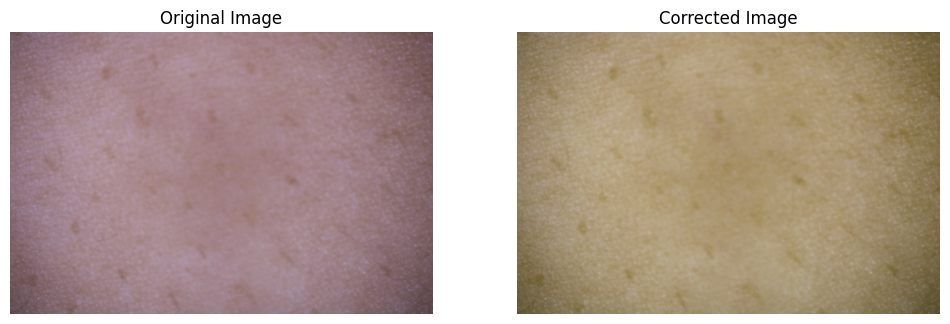

In [ ]:
img_idx = 70

img_name = df.iloc[img_idx]['isic_id'] + '.jpg'
img_path = os.path.join(imgs_folder, img_name)
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

color_in_img = df.iloc[img_idx][['img_l', 'img_a', 'img_b']].values
color_physical = df.iloc[img_idx][['average_l', 'average_a', 'average_b']].values

# map to openCV LAB range
color_in_img[0] = color_in_img[0] * (255 / 100)
color_in_img[1] = color_in_img[1] + 128
color_in_img[2] = color_in_img[2] + 128

color_physical[0] = color_physical[0] * (255 / 100)
color_physical[1] = color_physical[1] + 128
color_physical[2] = color_physical[2] + 128

print("Color in image (LAB): ", color_in_img)
print("Physical color (LAB): ", color_physical)

# correction value
correction_value = color_physical / color_in_img
print("Correction value (LAB): ", correction_value)

# Apply correction to the image
img_lab = cv.cvtColor(img, cv.COLOR_RGB2LAB).astype(np.float32)
img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(img_corrected)
plt.axis('off')
plt.show()

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

metadata_csv = 'data/mskcc/metadata.csv'
ita_csv = 'data/mskcc/s7.csv'

metadata_df = pd.read_csv(metadata_csv)
ita_df = pd.read_csv(ita_csv)

combined_df = pd.merge(metadata_df, ita_df, on='isic_id')

print(combined_df.columns)
combined_df.head()

Index(['isic_id', 'attribution', 'copyright_license', 'age_approx',
       'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy',
       'dermoscopic_type_x', 'diagnosis_1', 'diagnosis_2',
       'diagnosis_confirm_type', 'fitzpatrick_skin_type', 'image_type',
       'lesion_id', 'melanocytic', 'patient_id', 'sex', 'Unnamed: 0',
       'dermoscopic_type_y', 'img_l', 'img_a', 'img_b', 'img_ita', 'tag_id',
       'type', 'anatomic_site', 'l_1', 'l_2', 'l_3', 'average_l', 'a_1', 'a_2',
       'a_3', 'average_a', 'b_1', 'b_2', 'b_3', 'average_b', 'ita_1', 'ita_2',
       'ita_3', 'average_ita'],
      dtype='object')


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,dermoscopic_type_x,diagnosis_1,diagnosis_2,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,ISIC_0077599,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,anterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,10.0,11.33,23,23.0,26.0,24.00,8,8.0,6.0,7.33
1,ISIC_0086394,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,upper extremity,NaN,False,contact non-polarized,Benign,Benign - Other,...,2.0,2.00,16,16.0,15.0,15.66,49,50.0,50.0,49.66
2,ISIC_0087198,Memorial Sloan Kettering Cancer Center,CC-BY,45.0,lower extremity,acral palms or soles,False,non-contact polarized,Benign,Benign - Other,...,6.0,10.00,19,20.0,20.0,19.66,-27,-24.0,-22.0,-24.33
3,ISIC_0091914,Memorial Sloan Kettering Cancer Center,CC-BY,70.0,anterior torso,NaN,False,NaN,Benign,Benign - Other,...,3.0,2.33,10,10.0,10.0,10.00,66,66.0,64.0,65.33
4,ISIC_0092255,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,posterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,7.0,6.66,24,20.0,24.0,22.66,32,27.0,28.0,29.00


<Figure size 800x600 with 0 Axes>

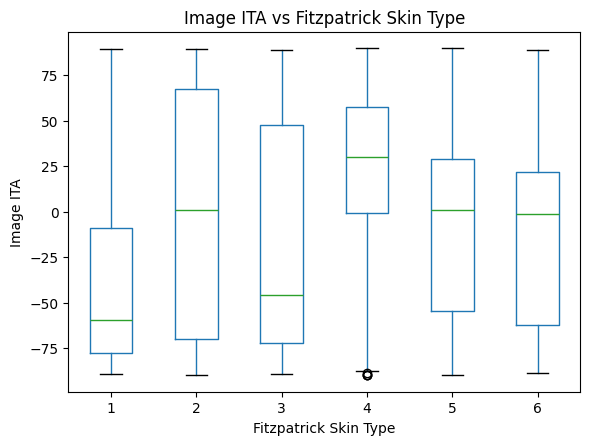

<Figure size 800x600 with 0 Axes>

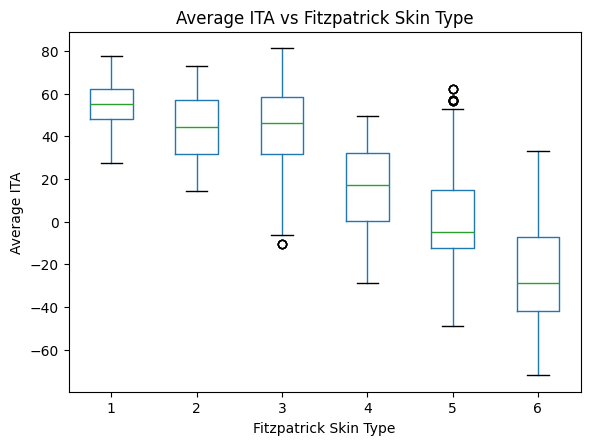

<Figure size 800x600 with 0 Axes>

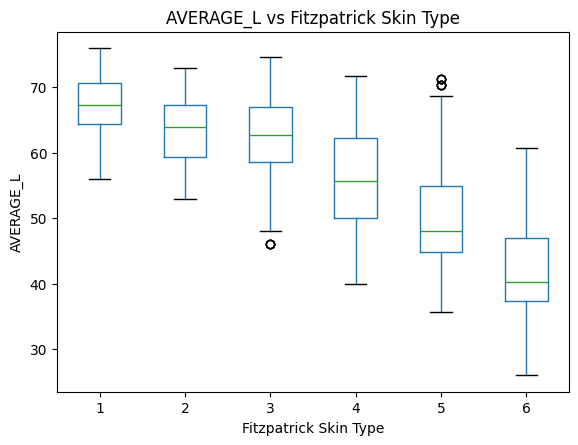

<Figure size 800x600 with 0 Axes>

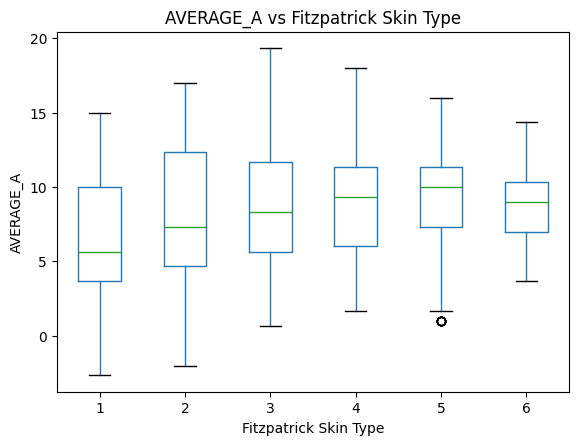

<Figure size 800x600 with 0 Axes>

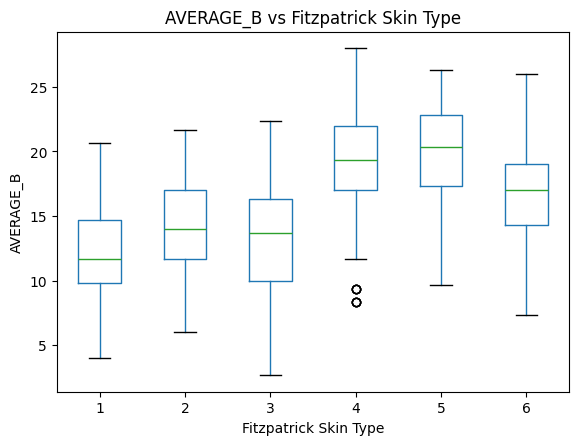

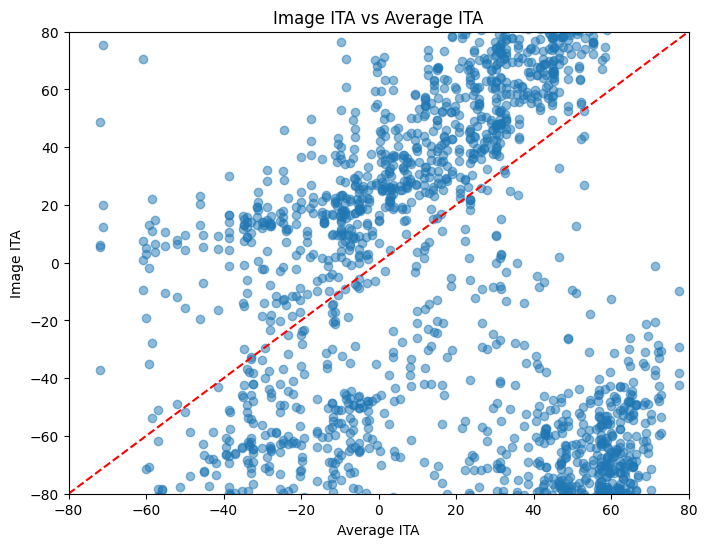

In [15]:
# plot image ita vs fitzpatrick
 
# ['IV' 'II' 'V' 'VI' 'I' 'III'] are the fitzpatrick skin types in the dataset
skin_type_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6}
combined_df['fitzpatrick_skin_type_num'] = combined_df['fitzpatrick_skin_type'].map(skin_type_mapping)

# img_ita, fitzpatrick_skin_type, box plot
plt.figure(figsize=(8, 6))
combined_df.boxplot(column='img_ita', by='fitzpatrick_skin_type_num', grid=False)
plt.title('Image ITA vs Fitzpatrick Skin Type')
plt.suptitle('')
plt.xlabel('Fitzpatrick Skin Type')
plt.ylabel('Image ITA')
plt.show()

# average_ita vs fitzpatrick_skin_type, box plot
plt.figure(figsize=(8, 6))
combined_df.boxplot(column='average_ita', by='fitzpatrick_skin_type_num', grid=False)
plt.title('Average ITA vs Fitzpatrick Skin Type')
plt.suptitle('')
plt.xlabel('Fitzpatrick Skin Type')
plt.ylabel('Average ITA')
plt.show()

# average_l, _a and _b vs fitzpatrick_skin_type, box plots
for channel in ['average_l', 'average_a', 'average_b']:
    plt.figure(figsize=(8, 6))
    combined_df.boxplot(column=channel, by='fitzpatrick_skin_type_num', grid=False)
    plt.title(f'{channel.upper()} vs Fitzpatrick Skin Type')
    plt.suptitle('')
    plt.xlabel('Fitzpatrick Skin Type')
    plt.ylabel(channel.upper())
    plt.show()


# plot correlation between img_ita and average_ita
plt.figure(figsize=(8, 6))
plt.scatter(combined_df['average_ita'], combined_df['img_ita'], alpha=0.5)
plt.title('Image ITA vs Average ITA')
plt.ylabel('Image ITA')
plt.xlabel('Average ITA')
# scale -80 to 80 both axes
plt.xlim(-80, 80)
plt.ylim(-80, 80)
# show diagonal line
plt.plot([-80, 80], [-80, 80], color='red', linestyle='--')
plt.show()

In [ ]:
# would white balancing help here?